In [ ]:
import os
import sys

module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from pycaret.clustering import setup, create_model, assign_model
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

from utils import preprocessing

# 폰트 설정
plt.rc("font", family="Malgun Gothic")
# 마이너스 부호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
warnings.filterwarnings("ignore")
DATA_PATH = "../data"
OUTPUT_DIR = "../results"
IMAGE_DIR = "../images"

document_df = preprocessing.get_default_data()

📂 51개 파일 발견
🔄 텍스트 전처리 시작...
   옵션: HTML제거=True, URL제거=True, 숫자제거=True
   옵션: 불용어제거=True, Lemmatization=True, Stemming=False
✅ 전처리 완료:
   - 원본 문서 수: 51
   - 제거된 빈 문서: 0
   - 최종 문서 수: 51
   - 평균 단어 수: 1266.9


In [ ]:
# =============================================================================
# 클러스터 유사도 분석 함수
# =============================================================================
def analyze_cluster_similarity(X, labels, algorithm_name):
    """
    클러스터 유사도 분석
    - 클러스터 내부 유사도 (Intra-cluster)
    - 클러스터 간 유사도 (Inter-cluster)
    """
    # 문자열 레이블을 숫자로 변환
    labels_numeric = np.array(
        [
            (
                int(str(label).replace("Cluster ", ""))
                if "Cluster" in str(label)
                else label
            )
            for label in labels
        ]
    )

    unique_clusters = sorted(set(labels_numeric))
    n_clusters = len(unique_clusters)

    print(f"\n{'='*70}")
    print(f"📊 {algorithm_name} - 클러스터 유사도 분석")
    print(f"{'='*70}")
    print(f"클러스터 수: {n_clusters}")
    print(f"총 문서 수: {len(labels_numeric)}\n")

    # 코사인 유사도 행렬 계산
    similarity_matrix = cosine_similarity(X)

    # 1. 클러스터별 내부 유사도 (Intra-cluster similarity)
    intra_cluster_similarities = {}
    cluster_sizes = {}

    print("🔹 클러스터 내부 유사도 (높을수록 클러스터가 응집력 있음)")
    print("-" * 70)

    for cluster_id in unique_clusters:
        # 해당 클러스터의 문서 인덱스
        cluster_mask = labels_numeric == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        cluster_sizes[cluster_id] = len(cluster_indices)

        if len(cluster_indices) > 1:
            # 클러스터 내 문서들 간의 유사도
            cluster_sim_matrix = similarity_matrix[cluster_indices][:, cluster_indices]
            # 대각선 제외 (자기 자신과의 유사도 제외)
            mask = ~np.eye(cluster_sim_matrix.shape[0], dtype=bool)
            intra_similarities = cluster_sim_matrix[mask]
            avg_intra_sim = np.mean(intra_similarities)
            std_intra_sim = np.std(intra_similarities)
            min_intra_sim = np.min(intra_similarities)
            max_intra_sim = np.max(intra_similarities)
        else:
            avg_intra_sim = 1.0
            std_intra_sim = 0.0
            min_intra_sim = 1.0
            max_intra_sim = 1.0

        intra_cluster_similarities[cluster_id] = {
            "mean": avg_intra_sim,
            "std": std_intra_sim,
            "min": min_intra_sim,
            "max": max_intra_sim,
            "size": cluster_sizes[cluster_id],
        }

        print(
            f"Cluster {cluster_id:2d} (크기: {cluster_sizes[cluster_id]:3d}) - "
            f"평균: {avg_intra_sim:.4f}, 표준편차: {std_intra_sim:.4f}, "
            f"범위: [{min_intra_sim:.4f}, {max_intra_sim:.4f}]"
        )

    # 2. 클러스터 간 유사도 (Inter-cluster similarity)
    print(f"\n🔹 클러스터 간 유사도 (낮을수록 클러스터가 잘 분리됨)")
    print("-" * 70)

    # 클러스터 중심점 계산 (평균 벡터)
    cluster_centers = []
    for cluster_id in unique_clusters:
        cluster_mask = labels_numeric == cluster_id
        cluster_docs = X[cluster_mask]
        center = np.mean(cluster_docs, axis=0)
        cluster_centers.append(center)

    cluster_centers = np.array(cluster_centers)

    # 클러스터 중심점 간 유사도
    inter_cluster_sim = cosine_similarity(cluster_centers)

    # 상위 5개 유사한 클러스터 쌍
    print("\n상위 5개 유사한 클러스터 쌍:")
    sim_pairs = []
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            sim_pairs.append(
                (unique_clusters[i], unique_clusters[j], inter_cluster_sim[i, j])
            )

    sim_pairs.sort(key=lambda x: x[2], reverse=True)
    for i, (c1, c2, sim) in enumerate(sim_pairs[:5], 1):
        print(f"{i}. Cluster {c1} ↔ Cluster {c2}: {sim:.4f}")

    # 하위 5개 유사한 클러스터 쌍 (가장 다른 클러스터)
    print("\n하위 5개 유사한 클러스터 쌍 (가장 구별됨):")
    for i, (c1, c2, sim) in enumerate(sim_pairs[-5:][::-1], 1):
        print(f"{i}. Cluster {c1} ↔ Cluster {c2}: {sim:.4f}")

    return (
        intra_cluster_similarities,
        inter_cluster_sim,
        unique_clusters,
        cluster_centers,
    )

In [ ]:
# =============================================================================
# 시각화 함수
# =============================================================================
def visualize_similarity(
    intra_similarities, inter_cluster_sim, unique_clusters, algorithm_name, output_dir
):
    """유사도 시각화"""

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # 1. 클러스터 내부 유사도 박스플롯
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1-1. 평균 내부 유사도
    clusters = list(intra_similarities.keys())
    means = [intra_similarities[c]["mean"] for c in clusters]
    sizes = [intra_similarities[c]["size"] for c in clusters]

    ax = axes[0, 0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))
    bars = ax.bar(range(len(clusters)), means, color=colors)
    ax.set_xlabel("Cluster ID", fontsize=11)
    ax.set_ylabel("평균 코사인 유사도", fontsize=11)
    ax.set_title(
        "클러스터 내부 유사도 (높을수록 응집력 있음)", fontsize=12, fontweight="bold"
    )
    ax.set_xticks(range(len(clusters)))
    ax.set_xticklabels(clusters)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(
        y=np.mean(means),
        color="r",
        linestyle="--",
        linewidth=1,
        label=f"전체 평균: {np.mean(means):.3f}",
    )
    ax.legend()

    # 값 표시
    for bar, val in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    # 1-2. 클러스터 크기
    ax = axes[0, 1]
    bars = ax.bar(range(len(clusters)), sizes, color=colors)
    ax.set_xlabel("Cluster ID", fontsize=11)
    ax.set_ylabel("문서 수", fontsize=11)
    ax.set_title("클러스터 크기 분포", fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(clusters)))
    ax.set_xticklabels(clusters)
    ax.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, sizes):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val,
            f"{val}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    # 2. 클러스터 간 유사도 히트맵
    ax = axes[1, 0]
    im = ax.imshow(inter_cluster_sim, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(unique_clusters)))
    ax.set_yticks(range(len(unique_clusters)))
    ax.set_xticklabels(unique_clusters, fontsize=9)
    ax.set_yticklabels(unique_clusters, fontsize=9)
    ax.set_xlabel("Cluster ID", fontsize=11)
    ax.set_ylabel("Cluster ID", fontsize=11)
    ax.set_title(
        "클러스터 간 유사도 (낮을수록 잘 분리됨)", fontsize=12, fontweight="bold"
    )

    # 값 표시
    for i in range(len(unique_clusters)):
        for j in range(len(unique_clusters)):
            if i != j:  # 대각선 제외
                text_color = "white" if inter_cluster_sim[i, j] > 0.5 else "black"
                ax.text(
                    j,
                    i,
                    f"{inter_cluster_sim[i, j]:.2f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=8,
                )

    plt.colorbar(im, ax=ax, label="코사인 유사도")

    # 3. 클러스터 품질 종합 점수
    ax = axes[1, 1]

    # 품질 점수 = 내부 유사도 높음 + 외부 유사도 낮음
    quality_scores = []
    for i, cluster_id in enumerate(clusters):
        intra_sim = intra_similarities[cluster_id]["mean"]
        # 해당 클러스터와 다른 클러스터들 간의 평균 유사도
        inter_sims = [inter_cluster_sim[i, j] for j in range(len(clusters)) if i != j]
        avg_inter_sim = np.mean(inter_sims) if inter_sims else 0
        # 품질 점수: 내부 유사도 - 외부 유사도
        quality_score = intra_sim - avg_inter_sim
        quality_scores.append(quality_score)

    colors_quality = ["green" if s > 0 else "red" for s in quality_scores]
    bars = ax.barh(
        range(len(clusters)), quality_scores, color=colors_quality, alpha=0.7
    )
    ax.set_yticks(range(len(clusters)))
    ax.set_yticklabels([f"Cluster {c}" for c in clusters], fontsize=9)
    ax.set_xlabel("품질 점수 (내부 유사도 - 외부 유사도)", fontsize=11)
    ax.set_title("클러스터 품질 점수 (높을수록 좋음)", fontsize=12, fontweight="bold")
    ax.axvline(x=0, color="black", linestyle="-", linewidth=1)
    ax.grid(axis="x", alpha=0.3)

    for bar, val in zip(bars, quality_scores):
        x_pos = val + 0.01 if val > 0 else val - 0.01
        ha = "left" if val > 0 else "right"
        ax.text(
            x_pos,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            ha=ha,
            va="center",
            fontsize=8,
        )

    plt.suptitle(
        f"{algorithm_name} - 클러스터 유사도 분석",
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()

    # 저장
    output_path = os.path.join(
        output_dir, f"{algorithm_name}_similarity_{timestamp}.png"
    )
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    return output_path

In [ ]:
# =============================================================================
# 클러스터별 대표 문서 추출
# =============================================================================
def get_representative_docs(X, labels, document_df, top_n=3):
    """각 클러스터의 대표 문서 추출 (중심에 가장 가까운 문서)"""

    # 문자열 레이블을 숫자로 변환
    labels_numeric = np.array(
        [
            (
                int(str(label).replace("Cluster ", ""))
                if "Cluster" in str(label)
                else label
            )
            for label in labels
        ]
    )

    unique_clusters = sorted(set(labels_numeric))
    representative_docs = {}

    for cluster_id in unique_clusters:
        cluster_mask = labels_numeric == cluster_id
        cluster_indices = np.where(cluster_mask)[0]

        if len(cluster_indices) == 0:
            continue

        # 클러스터 중심 계산
        cluster_docs = X[cluster_indices]
        center = np.mean(cluster_docs, axis=0)

        # 중심과의 거리 계산
        distances = euclidean_distances(cluster_docs, center.reshape(1, -1)).flatten()

        # 가장 가까운 top_n 문서
        closest_indices = np.argsort(distances)[:top_n]
        representative_indices = cluster_indices[closest_indices]

        representative_docs[cluster_id] = [
            {
                "doc_index": idx,
                "filename": document_df.iloc[idx]["filename"],
                "distance": distances[closest_indices[i]],
                "text_preview": document_df.iloc[idx]["opinion_text"][:200] + "...",
            }
            for i, idx in enumerate(representative_indices)
        ]

    return representative_docs


📊 클러스터 유사도 심층 분석

🔤 TF-IDF 벡터화 중...
✅ TF-IDF 행렬 생성: (51, 3203)

⚙️  PyCaret 환경 설정 중...
✅ PyCaret 설정 완료


🤖 K-Means 클러스터링 실행 중...


📊 K-Means - 클러스터 유사도 분석
클러스터 수: 7
총 문서 수: 51

🔹 클러스터 내부 유사도 (높을수록 클러스터가 응집력 있음)
----------------------------------------------------------------------
Cluster  0 (크기:   3) - 평균: 0.4133, 표준편차: 0.0981, 범위: [0.2972, 0.5371]
Cluster  1 (크기:  13) - 평균: 0.2939, 표준편차: 0.2273, 범위: [0.0365, 0.9241]
Cluster  2 (크기:   9) - 평균: 0.2300, 표준편차: 0.2461, 범위: [0.0351, 0.9644]
Cluster  3 (크기:   3) - 평균: 0.3939, 표준편차: 0.3998, 범위: [0.0807, 0.9581]
Cluster  4 (크기:   7) - 평균: 0.1466, 표준편차: 0.1018, 범위: [0.0373, 0.4386]
Cluster  5 (크기:   7) - 평균: 0.1896, 표준편차: 0.1468, 범위: [0.0224, 0.6893]
Cluster  6 (크기:   9) - 평균: 0.1721, 표준편차: 0.2466, 범위: [0.0112, 0.8934]

🔹 클러스터 간 유사도 (낮을수록 클러스터가 잘 분리됨)
----------------------------------------------------------------------

상위 5개 유사한 클러스터 쌍:
1. Cluster 0 ↔ Cluster 5: 0.4041
2. Cluster 1 ↔ Cluster 3: 0.3588
3. Cluster 0 ↔ Cluster 6: 0.2558
4. Cl

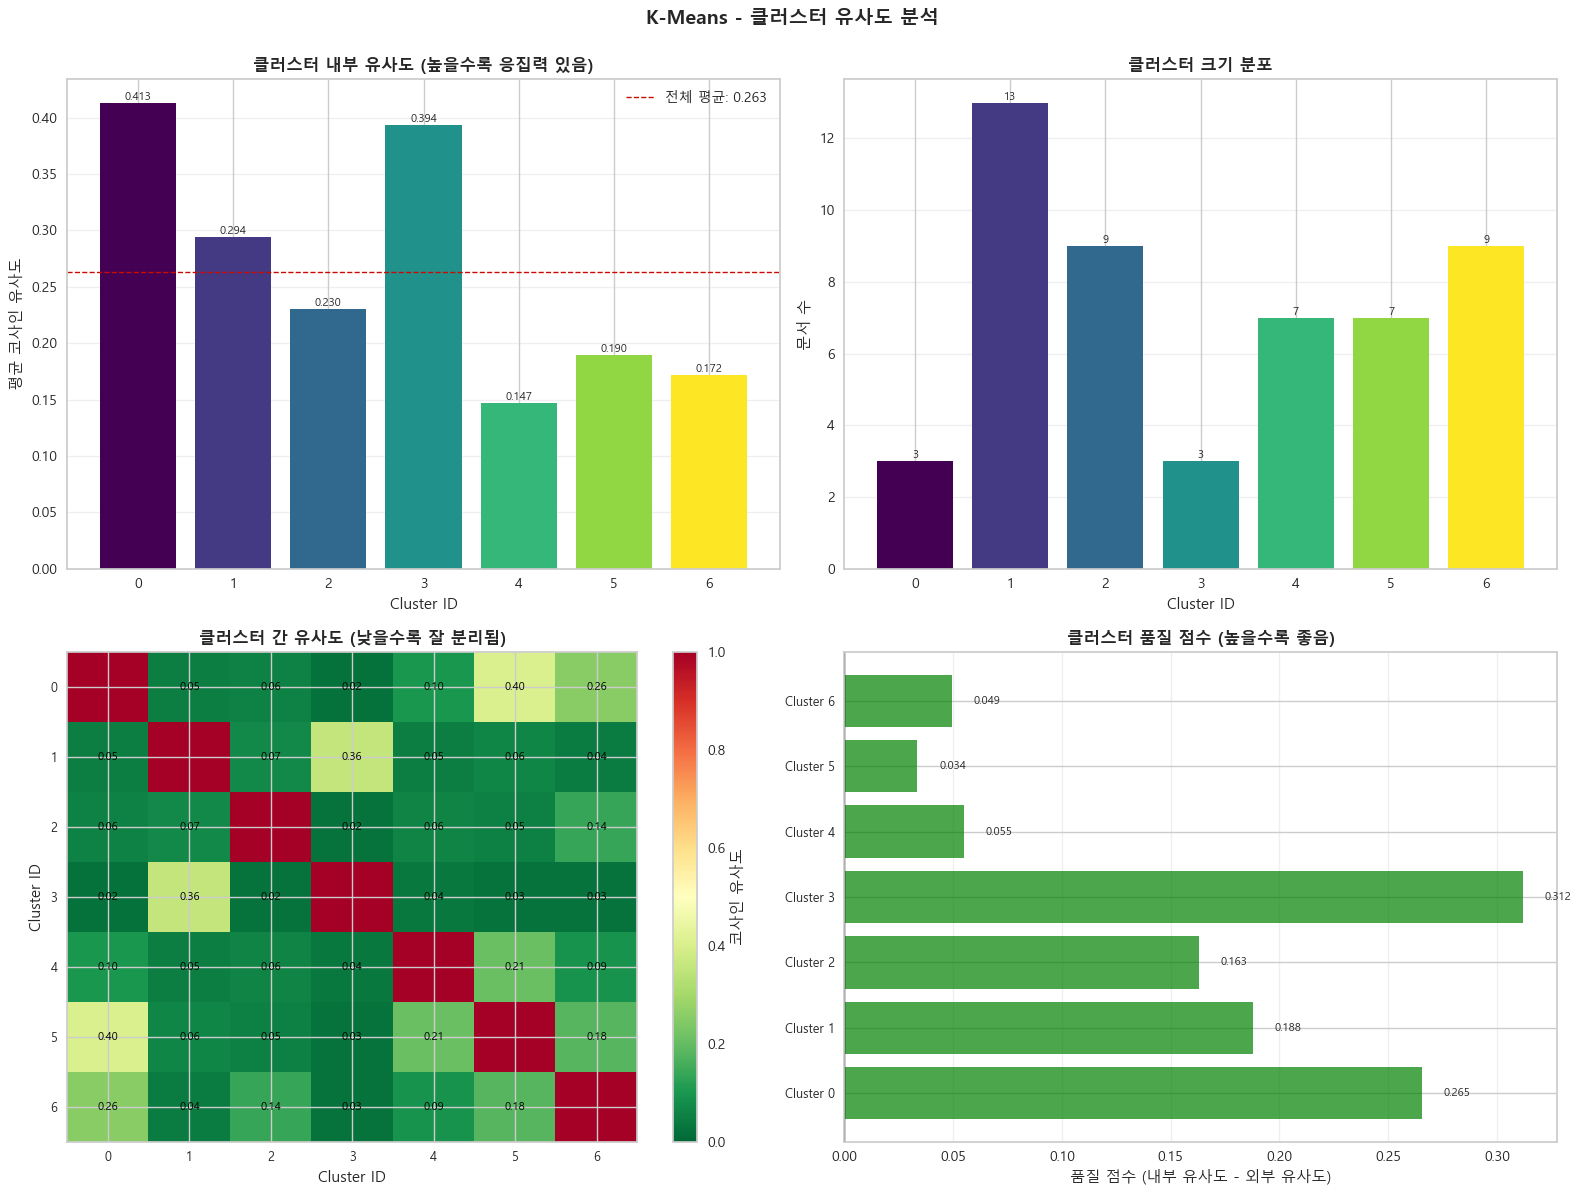


✅ 시각화 저장: ../images\K-Means_similarity_20251202_183310.png

🔍 클러스터별 대표 문서 추출 중...

🤖 Birch 클러스터링 실행 중...


📊 Birch - 클러스터 유사도 분석
클러스터 수: 7
총 문서 수: 51

🔹 클러스터 내부 유사도 (높을수록 클러스터가 응집력 있음)
----------------------------------------------------------------------
Cluster  0 (크기:   7) - 평균: 0.1466, 표준편차: 0.1018, 범위: [0.0373, 0.4386]
Cluster  1 (크기:  15) - 평균: 0.2554, 표준편차: 0.2207, 범위: [0.0365, 0.9581]
Cluster  2 (크기:  12) - 평균: 0.2038, 표준편차: 0.2306, 범위: [0.0112, 0.8934]
Cluster  3 (크기:   4) - 평균: 0.2561, 표준편차: 0.1097, 범위: [0.1565, 0.4171]
Cluster  4 (크기:   9) - 평균: 0.2300, 표준편차: 0.2461, 범위: [0.0351, 0.9644]
Cluster  5 (크기:   2) - 평균: 0.4714, 표준편차: 0.0000, 범위: [0.4714, 0.4714]
Cluster  6 (크기:   2) - 평균: 0.2523, 표준편차: 0.0000, 범위: [0.2523, 0.2523]

🔹 클러스터 간 유사도 (낮을수록 클러스터가 잘 분리됨)
----------------------------------------------------------------------

상위 5개 유사한 클러스터 쌍:
1. Cluster 1 ↔ Cluster 5: 0.2907
2. Cluster 2 ↔ Cluster 3: 0.1820
3. Cluster 3 ↔ Cluster 5: 0.1696
4. Cluster 0 ↔ Cluster 2: 0.162

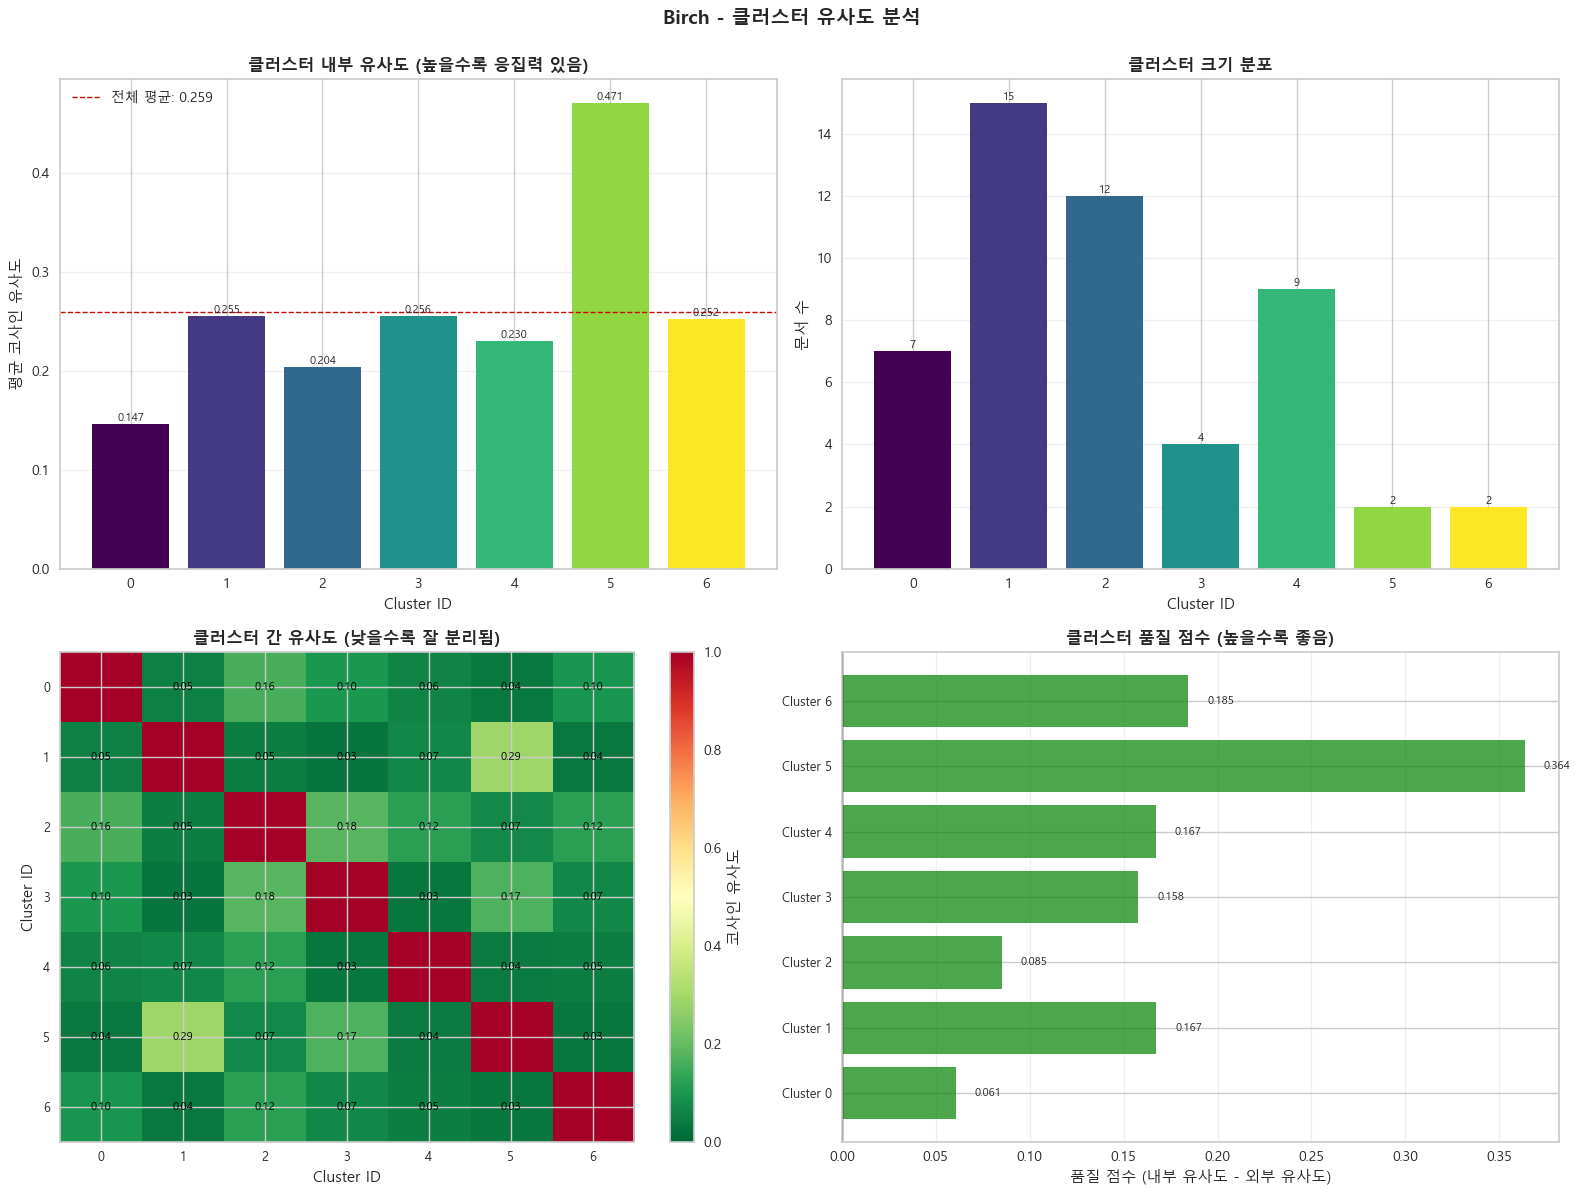


✅ 시각화 저장: ../images\Birch_similarity_20251202_183314.png

🔍 클러스터별 대표 문서 추출 중...

🤖 Agglomerative 클러스터링 실행 중...


📊 Agglomerative - 클러스터 유사도 분석
클러스터 수: 7
총 문서 수: 51

🔹 클러스터 내부 유사도 (높을수록 클러스터가 응집력 있음)
----------------------------------------------------------------------
Cluster  0 (크기:  13) - 평균: 0.2215, 표준편차: 0.2173, 범위: [0.0119, 0.9581]
Cluster  1 (크기:  19) - 평균: 0.0606, 표준편차: 0.0919, 범위: [0.0057, 0.6944]
Cluster  2 (크기:   5) - 평균: 0.4487, 표준편차: 0.2661, 범위: [0.1390, 0.9397]
Cluster  3 (크기:   3) - 평균: 0.8565, 표준편차: 0.0362, 범위: [0.8074, 0.8934]
Cluster  4 (크기:   5) - 평균: 0.4253, 표준편차: 0.2395, 범위: [0.1248, 0.8012]
Cluster  5 (크기:   4) - 평균: 0.6581, 표준편차: 0.2457, 범위: [0.3471, 0.9241]
Cluster  6 (크기:   2) - 평균: 0.9644, 표준편차: 0.0000, 범위: [0.9644, 0.9644]

🔹 클러스터 간 유사도 (낮을수록 클러스터가 잘 분리됨)
----------------------------------------------------------------------

상위 5개 유사한 클러스터 쌍:
1. Cluster 0 ↔ Cluster 5: 0.4283
2. Cluster 1 ↔ Cluster 4: 0.3155
3. Cluster 3 ↔ Cluster 4: 0.2131
4. Cluster 2 ↔ Cl

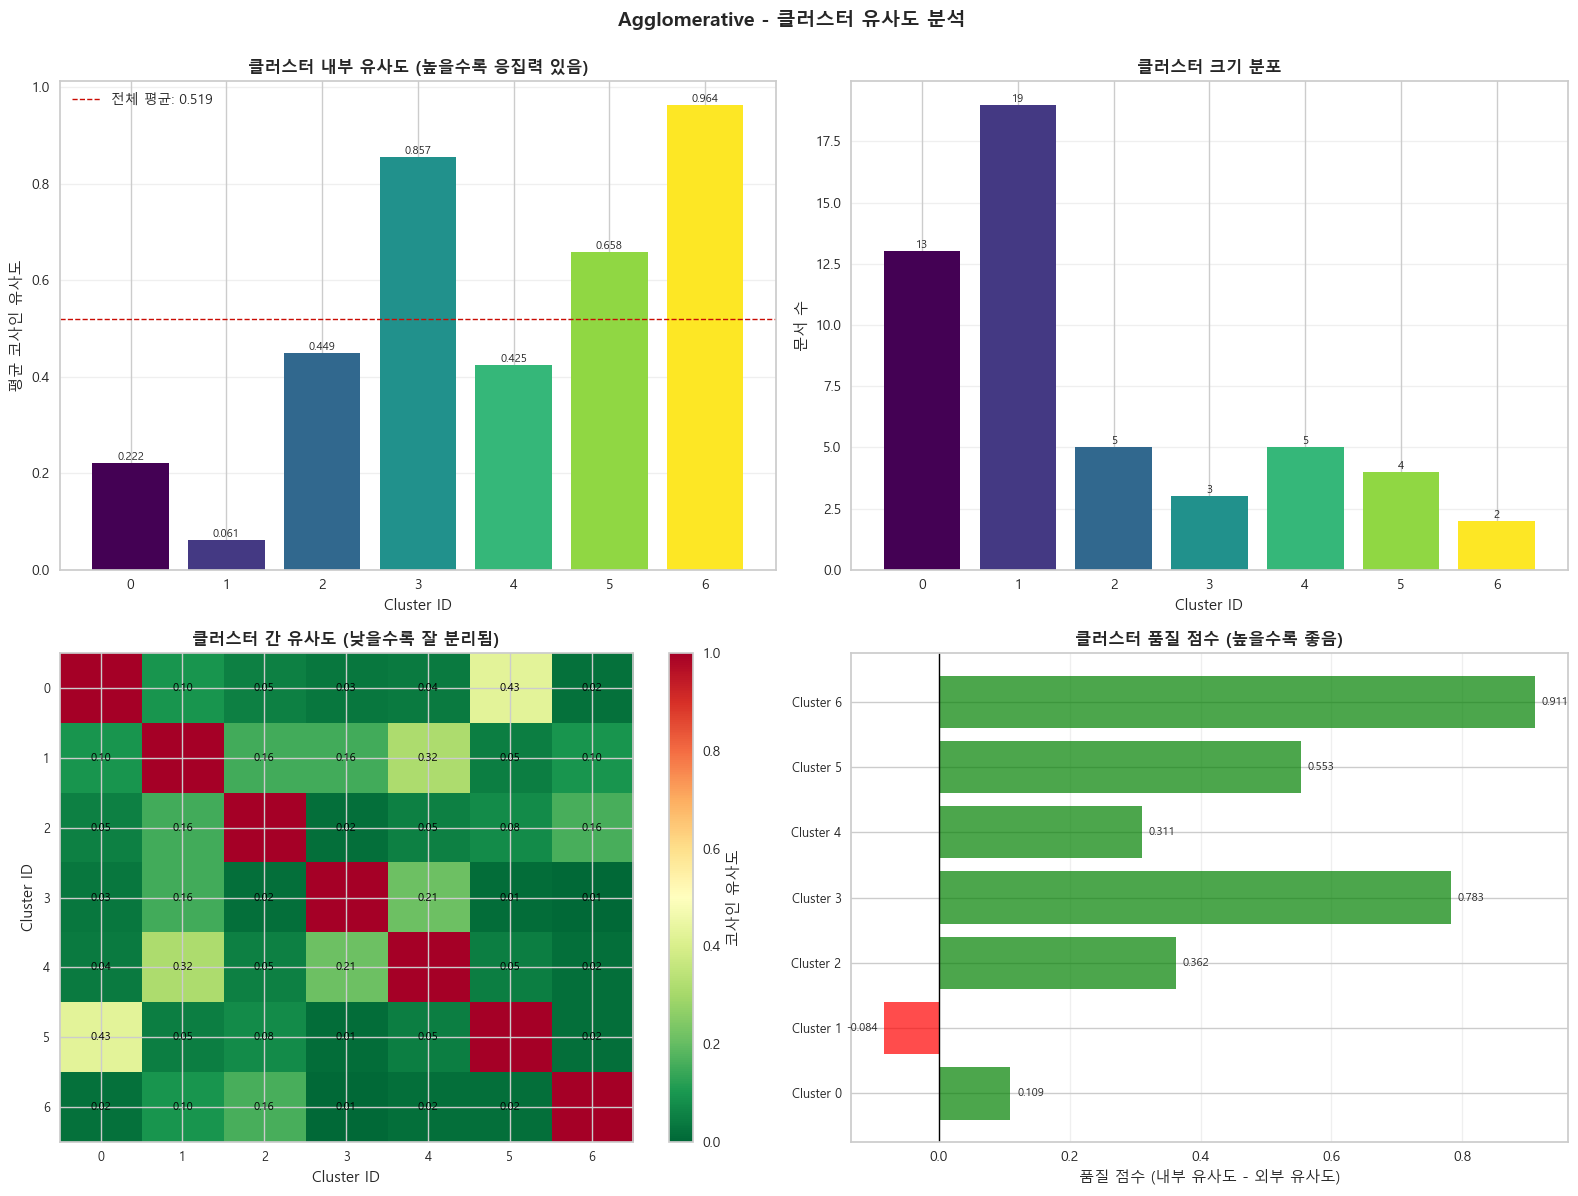


✅ 시각화 저장: ../images\Agglomerative_similarity_20251202_183318.png

🔍 클러스터별 대표 문서 추출 중...

🤖 Affinity Propagation 클러스터링 실행 중...


📊 Affinity Propagation - 클러스터 유사도 분석
클러스터 수: 17
총 문서 수: 51

🔹 클러스터 내부 유사도 (높을수록 클러스터가 응집력 있음)
----------------------------------------------------------------------
Cluster  0 (크기:   3) - 평균: 0.8565, 표준편차: 0.0362, 범위: [0.8074, 0.8934]
Cluster  1 (크기:   3) - 평균: 0.6734, 표준편차: 0.1442, 범위: [0.5053, 0.8573]
Cluster  2 (크기:   4) - 평균: 0.1631, 표준편차: 0.1089, 범위: [0.0380, 0.3455]
Cluster  3 (크기:   3) - 평균: 0.2479, 표준편차: 0.1425, 범위: [0.0961, 0.4386]
Cluster  4 (크기:   2) - 평균: 0.4171, 표준편차: 0.0000, 범위: [0.4171, 0.4171]
Cluster  5 (크기:   2) - 평균: 0.2523, 표준편차: 0.0000, 범위: [0.2523, 0.2523]
Cluster  6 (크기:   2) - 평균: 0.8821, 표준편차: 0.0000, 범위: [0.8821, 0.8821]
Cluster  7 (크기:   3) - 평균: 0.3718, 표준편차: 0.4190, 범위: [0.0680, 0.9644]
Cluster  8 (크기:   2) - 평균: 0.9397, 표준편차: 0.0000, 범위: [0.9397, 0.9397]
Cluster  9 (크기:   3) - 평균: 0.5005, 표준편차: 0.1534, 범위: [0.3379, 0.7062]
Cluste

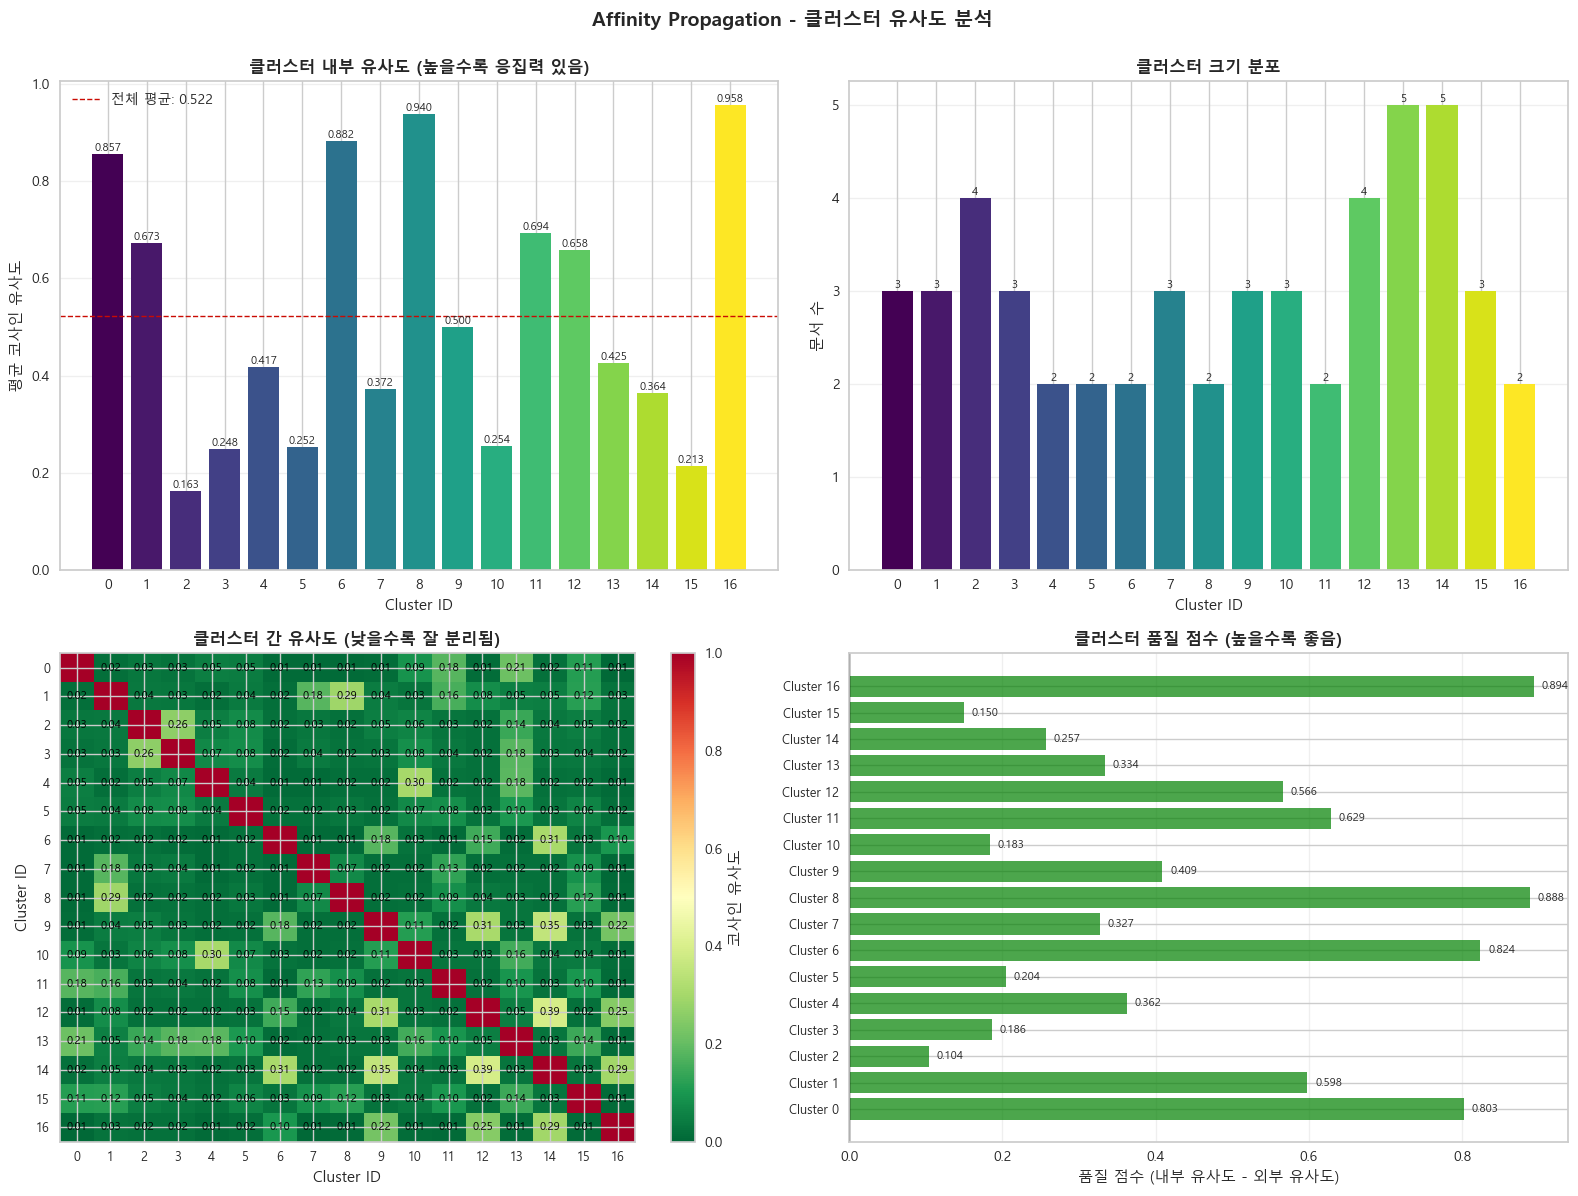


✅ 시각화 저장: ../images\Affinity Propagation_similarity_20251202_183322.png

🔍 클러스터별 대표 문서 추출 중...

🤖 DBSCAN 클러스터링 실행 중...


📊 DBSCAN - 클러스터 유사도 분석
클러스터 수: 1
총 문서 수: 51

🔹 클러스터 내부 유사도 (높을수록 클러스터가 응집력 있음)
----------------------------------------------------------------------
Cluster -1 (크기:  51) - 평균: 0.0659, 표준편차: 0.1286, 범위: [0.0037, 0.9644]

🔹 클러스터 간 유사도 (낮을수록 클러스터가 잘 분리됨)
----------------------------------------------------------------------

상위 5개 유사한 클러스터 쌍:

하위 5개 유사한 클러스터 쌍 (가장 구별됨):


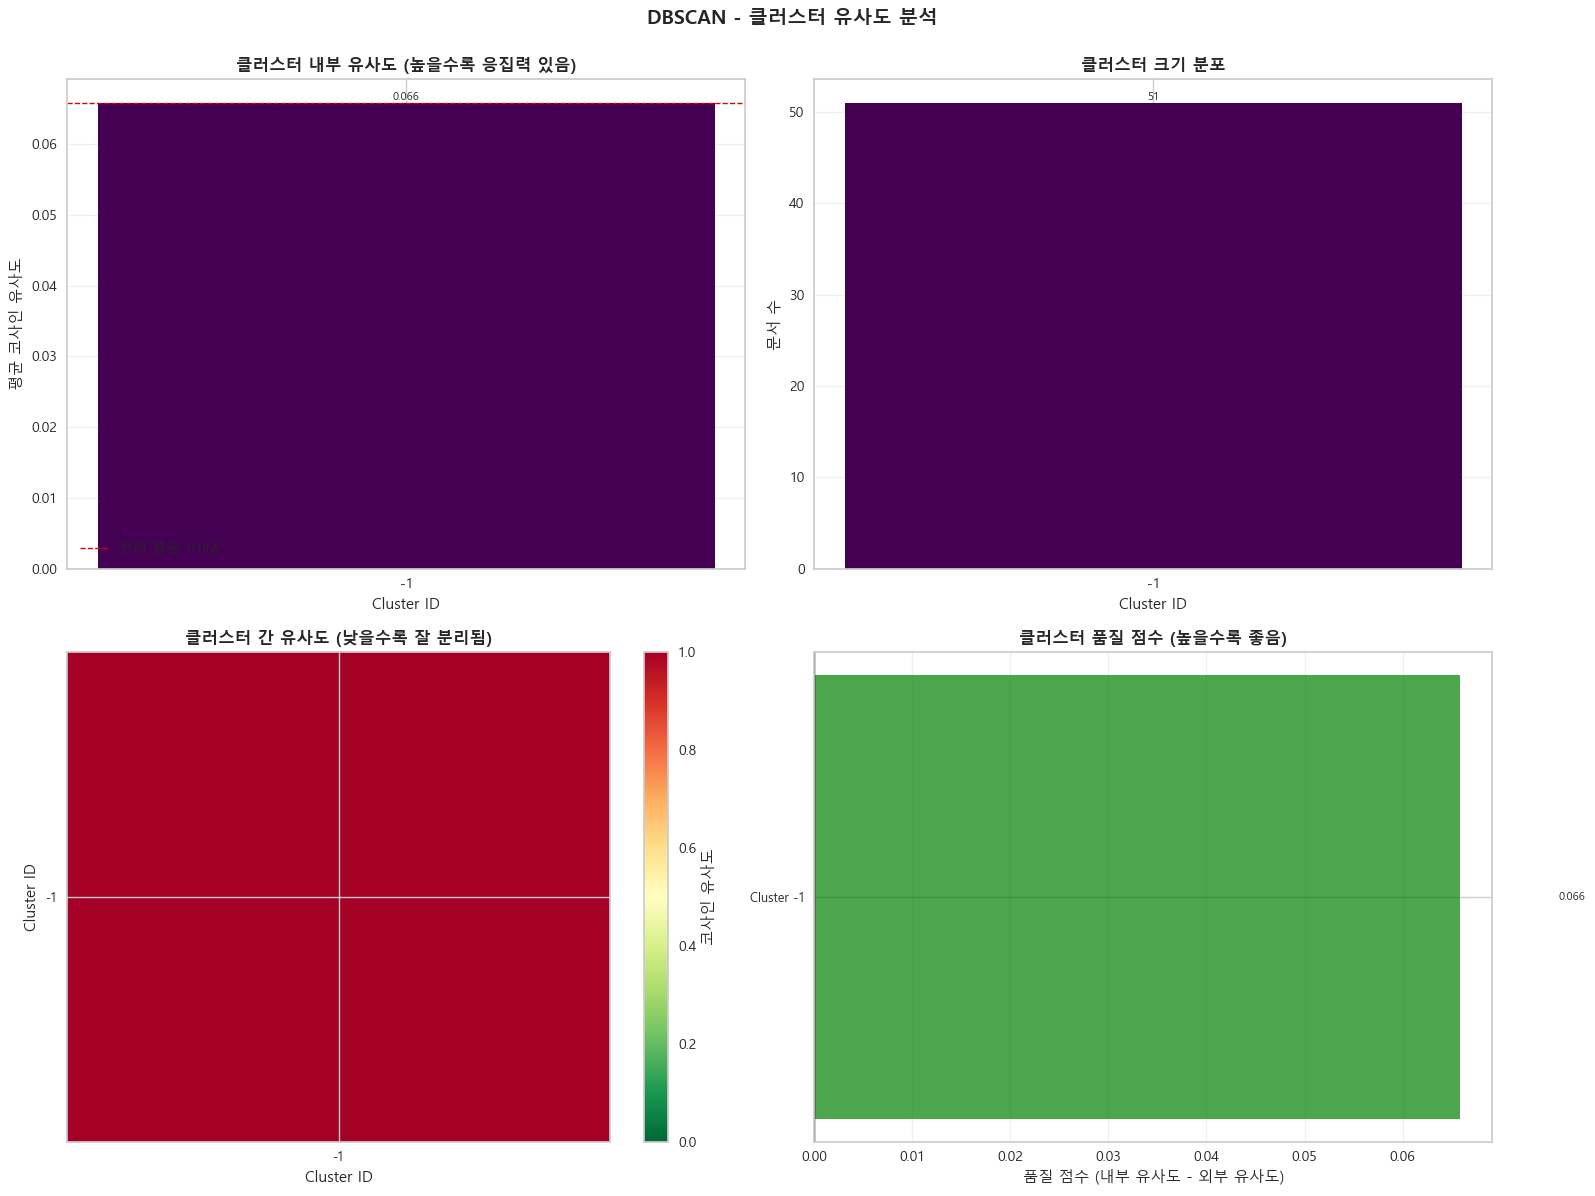


✅ 시각화 저장: ../images\DBSCAN_similarity_20251202_183327.png

🔍 클러스터별 대표 문서 추출 중...

🤖 Spectral Clustering 클러스터링 실행 중...


📊 Spectral Clustering - 클러스터 유사도 분석
클러스터 수: 7
총 문서 수: 51

🔹 클러스터 내부 유사도 (높을수록 클러스터가 응집력 있음)
----------------------------------------------------------------------
Cluster  0 (크기:   4) - 평균: 0.6581, 표준편차: 0.2457, 범위: [0.3471, 0.9241]
Cluster  1 (크기:   5) - 평균: 0.5437, 표준편차: 0.2895, 범위: [0.2496, 0.9140]
Cluster  2 (크기:  30) - 평균: 0.0639, 표준편차: 0.1076, 범위: [0.0037, 0.8012]
Cluster  3 (크기:   3) - 평균: 0.8565, 표준편차: 0.0362, 범위: [0.8074, 0.8934]
Cluster  4 (크기:   2) - 평균: 0.9644, 표준편차: 0.0000, 범위: [0.9644, 0.9644]
Cluster  5 (크기:   5) - 평균: 0.4487, 표준편차: 0.2661, 범위: [0.1390, 0.9397]
Cluster  6 (크기:   2) - 평균: 0.9581, 표준편차: 0.0000, 범위: [0.9581, 0.9581]

🔹 클러스터 간 유사도 (낮을수록 클러스터가 잘 분리됨)
----------------------------------------------------------------------

상위 5개 유사한 클러스터 쌍:
1. Cluster 0 ↔ Cluster 1: 0.3580
2. Cluster 1 ↔ Cluster 6: 0.2585
3. Cluster 0 ↔ Cluster 6: 0.2529
4. C

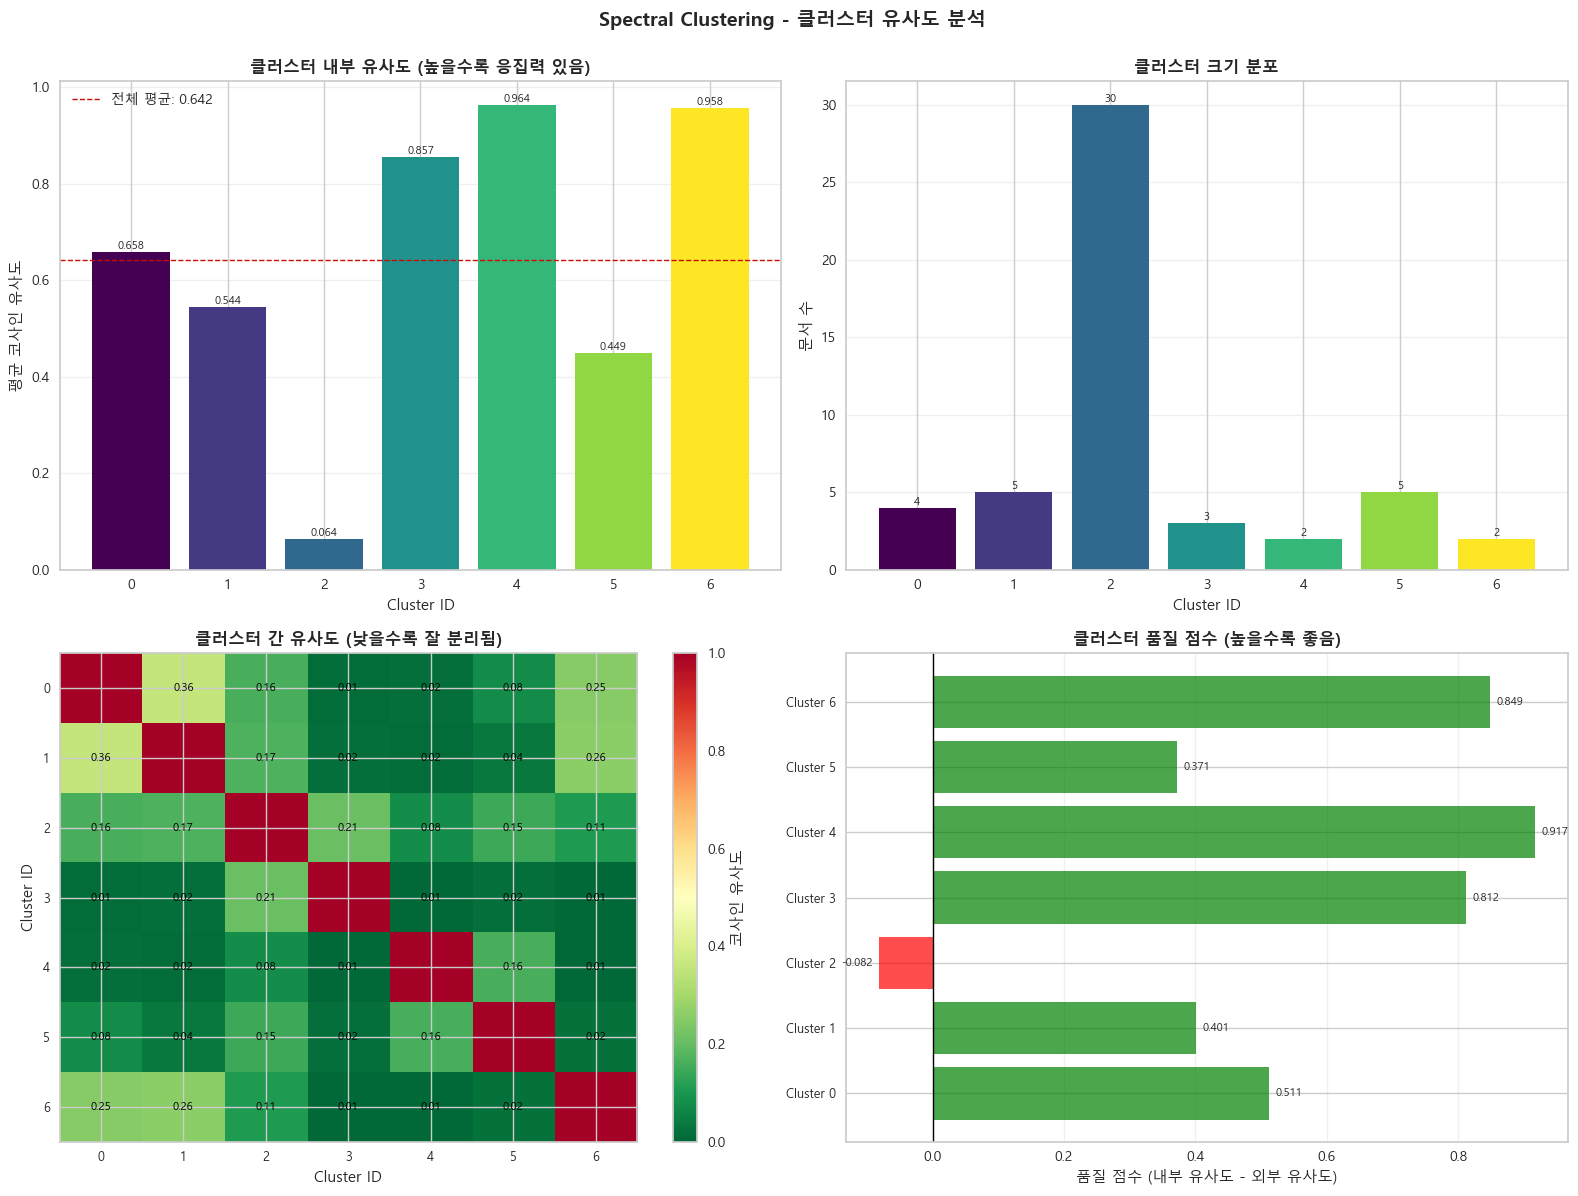


✅ 시각화 저장: ../images\Spectral Clustering_similarity_20251202_183330.png

🔍 클러스터별 대표 문서 추출 중...

🤖 OPTICS 클러스터링 실행 중...


📊 OPTICS - 클러스터 유사도 분석
클러스터 수: 2
총 문서 수: 51

🔹 클러스터 내부 유사도 (높을수록 클러스터가 응집력 있음)
----------------------------------------------------------------------
Cluster -1 (크기:  37) - 평균: 0.0674, 표준편차: 0.1235, 범위: [0.0037, 0.9644]
Cluster  0 (크기:  14) - 평균: 0.3021, 표준편차: 0.2189, 범위: [0.0426, 0.9581]

🔹 클러스터 간 유사도 (낮을수록 클러스터가 잘 분리됨)
----------------------------------------------------------------------

상위 5개 유사한 클러스터 쌍:
1. Cluster -1 ↔ Cluster 0: 0.1243

하위 5개 유사한 클러스터 쌍 (가장 구별됨):
1. Cluster -1 ↔ Cluster 0: 0.1243


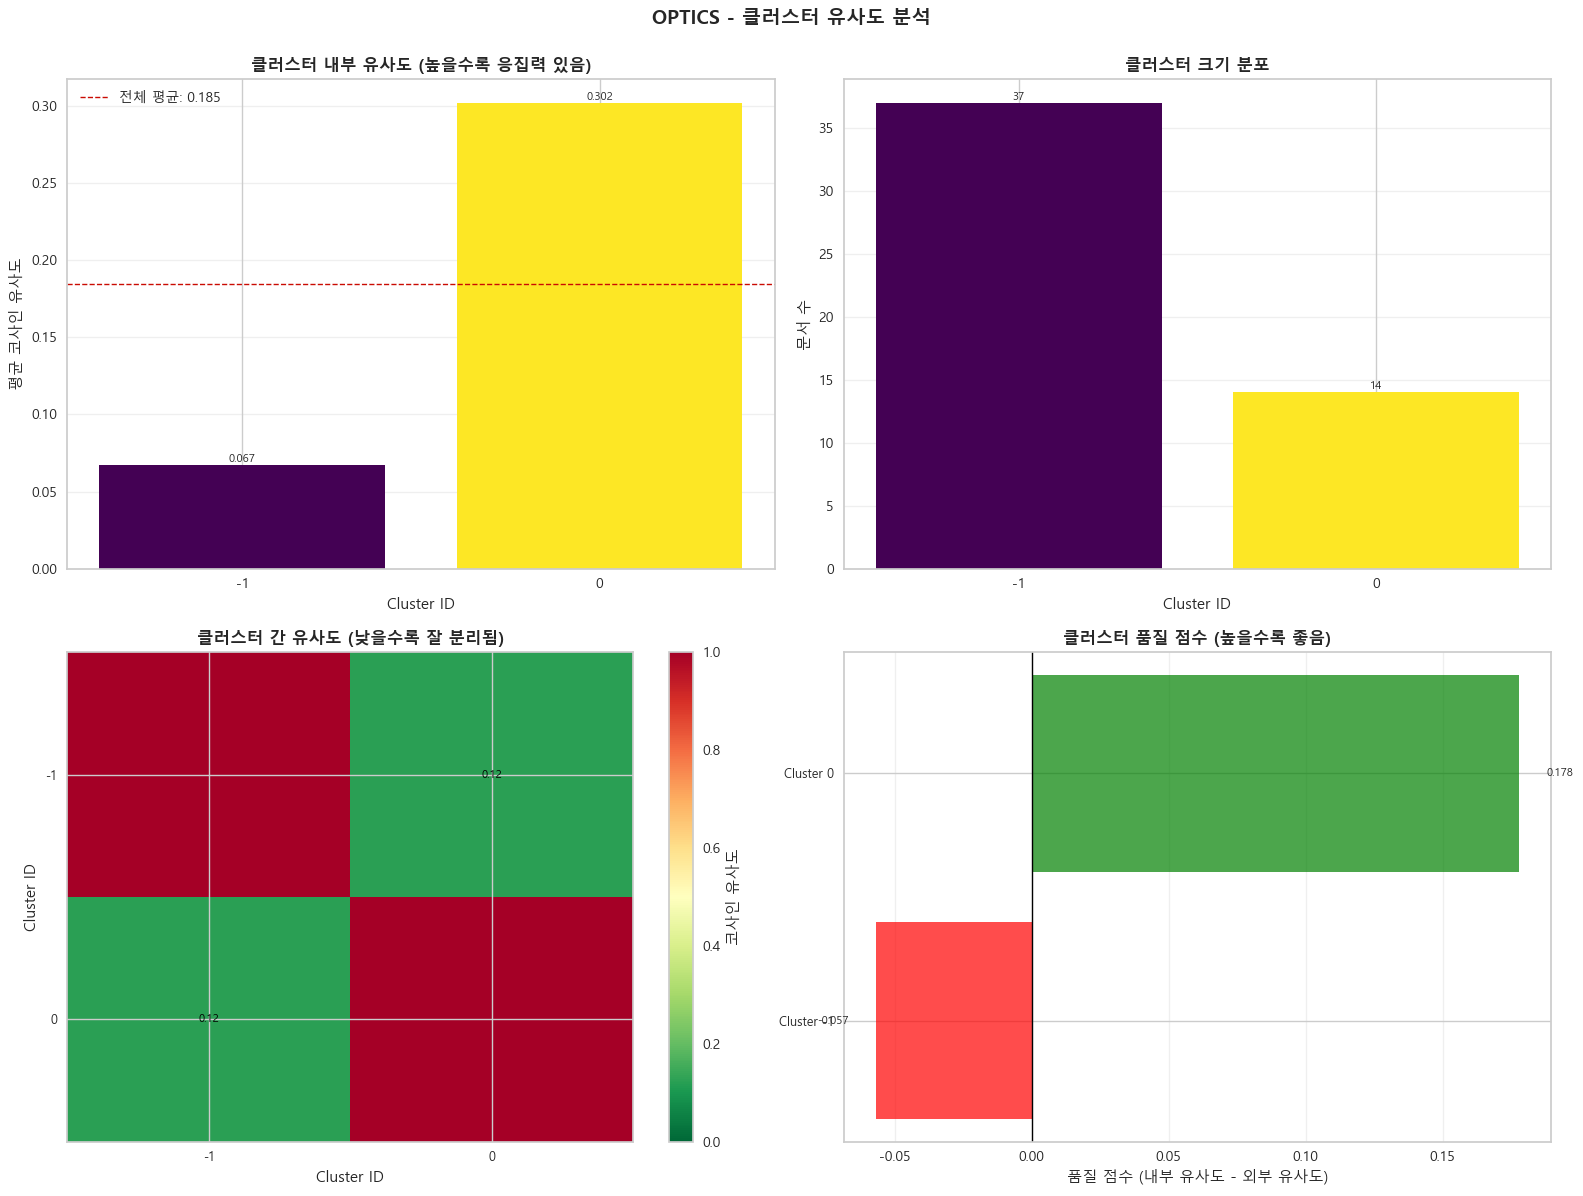


✅ 시각화 저장: ../images\OPTICS_similarity_20251202_183334.png

🔍 클러스터별 대표 문서 추출 중...

🤖 Mean Shift 클러스터링 실행 중...


📊 Mean Shift - 클러스터 유사도 분석
클러스터 수: 1
총 문서 수: 51

🔹 클러스터 내부 유사도 (높을수록 클러스터가 응집력 있음)
----------------------------------------------------------------------
Cluster  0 (크기:  51) - 평균: 0.0659, 표준편차: 0.1286, 범위: [0.0037, 0.9644]

🔹 클러스터 간 유사도 (낮을수록 클러스터가 잘 분리됨)
----------------------------------------------------------------------

상위 5개 유사한 클러스터 쌍:

하위 5개 유사한 클러스터 쌍 (가장 구별됨):


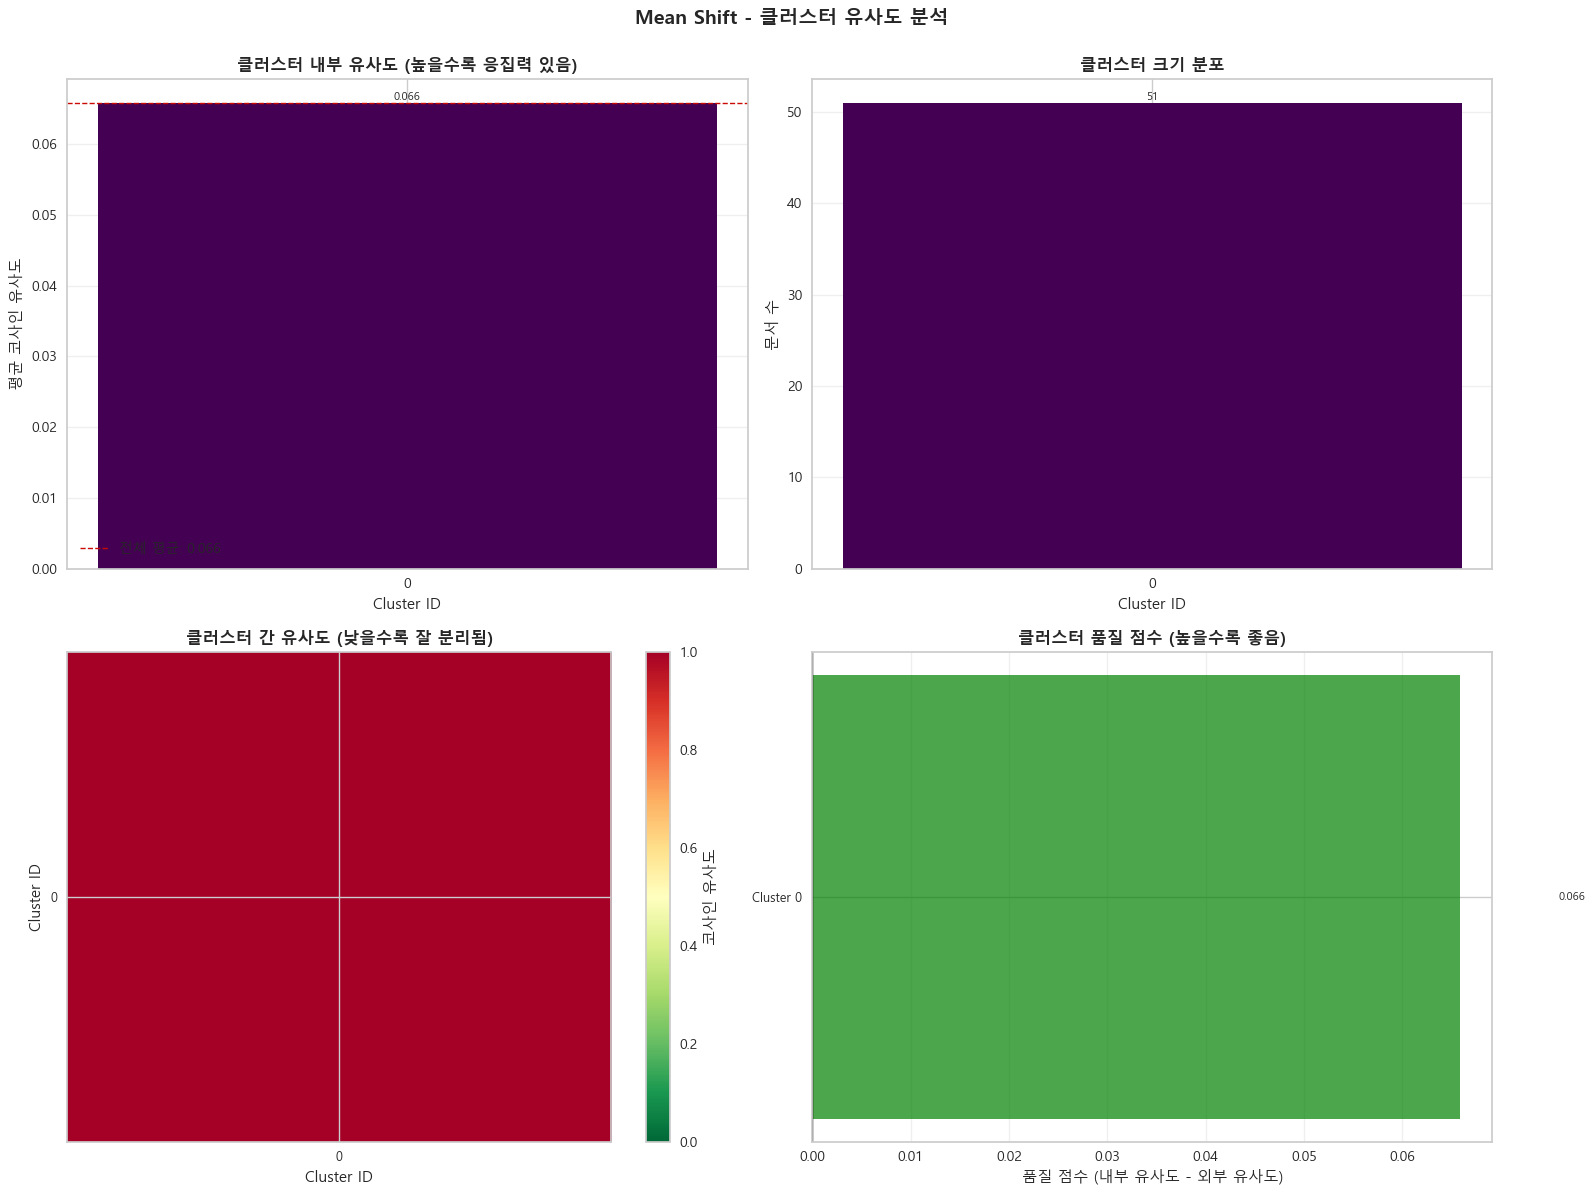


✅ 시각화 저장: ../images\Mean Shift_similarity_20251202_183341.png

🔍 클러스터별 대표 문서 추출 중...

✨ 분석 완료!

📁 결과 파일:
   - ../results\similarity_analysis_20251202_183258.txt
   - ../images/



In [ ]:
# =============================================================================
# 메인 실행
# =============================================================================
if __name__ == "__main__":
    # 경로 설정
    DATA_PATH = "../data"
    OUTPUT_DIR = "../results"
    IMAGE_DIR = "../images"

    print(f"\n{'='*70}")
    print("📊 클러스터 유사도 심층 분석")
    print(f"{'='*70}\n")

    # TF-IDF 벡터화
    print("🔤 TF-IDF 벡터화 중...")
    vectorizer = TfidfVectorizer(
        stop_words="english", max_features=5000, min_df=2, max_df=0.8
    )
    X = vectorizer.fit_transform(document_df["processed_text"].astype(str))
    X_dense = X.toarray()
    tfidf_df = pd.DataFrame(X_dense, columns=vectorizer.get_feature_names_out())
    print(f"✅ TF-IDF 행렬 생성: {tfidf_df.shape}\n")

    # 디렉토리 생성
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(IMAGE_DIR, exist_ok=True)

    # PyCaret Setup
    print("⚙️  PyCaret 환경 설정 중...")
    s = setup(data=tfidf_df, session_id=42, verbose=False, html=False, system_log=False)
    print("✅ PyCaret 설정 완료\n")

    # 클러스터 수 추정
    n_clusters = max(2, int(np.sqrt(len(document_df))))

    # 분석할 알고리즘 선택
    algorithms_to_analyze = {
        "kmeans": "K-Means",
        "birch": "Birch",
        "hclust": "Agglomerative",
        "ap": "Affinity Propagation",
        "dbscan": "DBSCAN",
        "sc": "Spectral Clustering",
        "optics": "OPTICS",
        "meanshift": "Mean Shift",
    }

    all_results = {}

    # 각 알고리즘에 대해 분석
    for model_id, model_name in algorithms_to_analyze.items():
        print(f"\n{'='*70}")
        print(f"🤖 {model_name} 클러스터링 실행 중...")
        print(f"{'='*70}\n")

        try:
            if model_id in ["ap", "meanshift", "dbscan", "optics"]:
                # n_clusters가 필요 없는 모델
                model = create_model(model_id, verbose=False)
            else:
                # n_clusters가 필요한 모델 (kmeans, birch, hclust, sc, kmodes)
                model = create_model(model_id, num_clusters=n_clusters, verbose=False)

            # 클러스터 할당
            clustered_data = assign_model(model)
            labels = clustered_data["Cluster"].values

            # 유사도 분석
            intra_sims, inter_sim, unique_clusters, centers = (
                analyze_cluster_similarity(X_dense, labels, model_name)
            )

            # 시각화
            output_path = visualize_similarity(
                intra_sims, inter_sim, unique_clusters, model_name, IMAGE_DIR
            )
            print(f"\n✅ 시각화 저장: {output_path}")

            # 대표 문서 추출
            print(f"\n🔍 클러스터별 대표 문서 추출 중...")
            rep_docs = get_representative_docs(X_dense, labels, document_df, top_n=3)

            all_results[model_name] = {
                "intra_similarities": intra_sims,
                "inter_similarity": inter_sim,
                "representative_docs": rep_docs,
                "labels": labels,
            }

        except Exception as e:
            print(f"❌ {model_name} 분석 실패: {str(e)}")
            continue

    # 결과 텍스트 파일 저장
    results_path = os.path.join(OUTPUT_DIR, f"similarity_analysis_{timestamp}.txt")
    with open(results_path, "w", encoding="utf-8") as f:
        f.write("=" * 70 + "\n")
        f.write("클러스터 유사도 분석 결과\n")
        f.write("=" * 70 + "\n\n")
        f.write(f"분석 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"문서 수: {len(document_df)}\n\n")

        for model_name, results in all_results.items():
            f.write("=" * 70 + "\n")
            f.write(f"{model_name}\n")
            f.write("=" * 70 + "\n\n")

            f.write("### 클러스터 내부 유사도 ###\n")
            for cluster_id, stats in results["intra_similarities"].items():
                f.write(f"\nCluster {cluster_id} (크기: {stats['size']})\n")
                f.write(f"  - 평균: {stats['mean']:.4f}\n")
                f.write(f"  - 표준편차: {stats['std']:.4f}\n")
                f.write(f"  - 범위: [{stats['min']:.4f}, {stats['max']:.4f}]\n")

            f.write("\n### 클러스터별 대표 문서 ###\n")
            for cluster_id, docs in results["representative_docs"].items():
                f.write(f"\nCluster {cluster_id}:\n")
                for i, doc in enumerate(docs, 1):
                    f.write(f"  {i}. {doc['filename']} (거리: {doc['distance']:.4f})\n")
                    f.write(f"     미리보기: {doc['text_preview']}\n")

            f.write("\n\n")

    print(f"\n{'='*70}")
    print("✨ 분석 완료!")
    print(f"{'='*70}")
    print(f"\n📁 결과 파일:")
    print(f"   - {results_path}")
    print(f"   - {IMAGE_DIR}/")
    print(f"{'='*70}\n")